# League of Legends Champions EDA

## Introduction
This project analyzes a [League of Legends champions dataset from Kaggle](https://www.kaggle.com/datasets/laurenainsleyhaines/patch-25-11-league-of-legends-champion-data-2025/data) to explore the data, perform basic cleaning, manipulation and visualisations.

## Load the Data

Import the required libraries and load the raw CSV, using the champion name as the index.

In [1]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


file_path = "../data/050625_LoL_champion_data.csv"
champion_data = pd.read_csv(file_path, index_col=0)

## First Look at the Data

Preview the first few rows to see what a champion record looks like.

In [2]:
champion_data.head()

,id,apiname,title,difficulty,herotype,alttype,resource,stats,rangetype,date,...,be,rp,skill_i,skill_q,skill_w,skill_e,skill_r,skills,fullname,nickname
Aatrox,266.0,Aatrox,the Darkin Blade,2,Fighter,Tank,Blood Well,"{'hp_base': 650, 'hp_lvl': 114, 'mp_base': 0, ...",Melee,2013-06-13,...,2400,880,{1: 'Deathbringer Stance'},"{1: 'The Darkin Blade', 2: 'The Darkin Blade 3'}",{1: 'Infernal Chains'},{1: 'Umbral Dash'},{1: 'World Ender'},"{1: 'Deathbringer Stance', 2: 'The Darkin Blad...",NaN,NaN
Ahri,103.0,Ahri,the Nine-Tailed Fox,2,Mage,Assassin,Mana,"{'hp_base': 590, 'hp_lvl': 104, 'mp_base': 418...",Ranged,2011-12-14,...,1575,790,{1: 'Essence Theft'},{1: 'Orb of Deception'},{1: 'Fox-Fire'},{1: 'Charm'},{1: 'Spirit Rush'},"{1: 'Essence Theft', 2: 'Orb of Deception', 3:...",NaN,NaN
Akali,84.0,Akali,the Rogue Assassin,2,Assassin,NaN,Energy,"{'hp_base': 600, 'hp_lvl': 119, 'mp_base': 200...",Melee,2010-05-11,...,1575,790,"{1: ""Assassin's Mark""}",{1: 'Five Point Strike'},{1: 'Twilight Shroud'},{1: 'Shuriken Flip'},{1: 'Perfect Execution'},"{1: ""Assassin's Mark"", 2: 'Five Point Strike',...",Akali Jhomen Tethi,NaN
Akshan,166.0,Akshan,the Rogue Sentinel,3,Marksman,Assassin,Mana,"{'hp_base': 630, 'hp_lvl': 107, 'mp_base': 350...",Ranged,2021-07-22,...,2400,880,{1: 'Dirty Fighting'},{1: 'Avengerang'},{1: 'Going Rogue'},{1: 'Heroic Swing'},{1: 'Comeuppance'},"{1: 'Dirty Fighting', 2: 'Avengerang', 3: 'Goi...",NaN,NaN
Alistar,12.0,Alistar,the Minotaur,1,Tank,Support,Mana,"{'hp_base': 685, 'hp_lvl': 120, 'mp_base': 350...",Melee,2009-02-21,...,675,585,{1: 'Triumphant Roar'},{1: 'Pulverize'},{1: 'Headbutt'},{1: 'Trample'},{1: 'Unbreakable Will'},"{1: 'Triumphant Roar', 2: 'Pulverize', 3: 'Hea...",NaN,NaN


List every column to know what's available to work with.

In [3]:
champion_data.columns.to_list()

['id',
 'apiname',
 'title',
 'difficulty',
 'herotype',
 'alttype',
 'resource',
 'stats',
 'rangetype',
 'date',
 'patch',
 'changes',
 'role',
 'client_positions',
 'external_positions',
 'damage',
 'toughness',
 'control',
 'mobility',
 'utility',
 'style',
 'adaptivetype',
 'be',
 'rp',
 'skill_i',
 'skill_q',
 'skill_w',
 'skill_e',
 'skill_r',
 'skills',
 'fullname',
 'nickname']

Check the data types. `stats` stands out as a column. It turns out to hold a Python-dict-formatted string of numeric stats that needs to be unpacked later.

In [4]:
champion_data.dtypes

id                    float64
apiname                object
title                  object
difficulty              int64
herotype               object
alttype                object
resource               object
stats                  object
rangetype              object
date                   object
patch                  object
changes                object
role                   object
client_positions       object
external_positions     object
damage                  int64
toughness               int64
control                 int64
mobility                int64
utility                 int64
style                   int64
adaptivetype           object
be                      int64
rp                      int64
skill_i                object
skill_q                object
skill_w                object
skill_e                object
skill_r                object
skills                 object
fullname               object
nickname               object
dtype: object

Peek at one raw `stats` value to confirm the nested, dict-like structure mentioned above.

In [5]:
champion_data['stats'].iloc[0]

"{'hp_base': 650, 'hp_lvl': 114, 'mp_base': 0, 'mp_lvl': 0, 'arm_base': 38, 'arm_lvl': 4.8, 'mr_base': 32, 'mr_lvl': 2.05, 'hp5_base': 3, 'hp5_lvl': 0.5, 'mp5_base': 0, 'mp5_lvl': 0, 'dam_base': 60, 'dam_lvl': 5, 'as_base': 0.651, 'as_lvl': 2.5, 'range': 175, 'ms': 345, 'acquisition_radius': 475, 'selection_height': 180, 'selection_radius': 135, 'pathing_radius': 35, 'as_ratio': 0.651000022888183, 'attack_cast_time': 0.300000011920928, 'attack_total_time': 1.51999998092651, 'aram': {'dmg_dealt': 1.05, 'dmg_taken': 1}, 'urf': {'dmg_dealt': 1.15, 'dmg_taken': 0.7}}"

## Categorical Column Distributions

Before cleaning anything, check the value counts of the key categorical columns to understand what categories exist and whether any look inconsistent or sparse.

In [6]:
champion_data['herotype'].value_counts()

herotype
Fighter     49
Mage        37
Marksman    28
Tank        24
Assassin    17
Support     17
Name: count, dtype: int64

In [7]:
champion_data['alttype'].value_counts()

alttype
Mage        38
Assassin    31
Support     28
Tank        25
Fighter     17
Marksman     5
Name: count, dtype: int64

In [8]:
champion_data['rangetype'].value_counts()

rangetype
Melee     91
Ranged    81
Name: count, dtype: int64

In [9]:
champion_data['difficulty'].value_counts()

difficulty
2    92
1    51
3    29
Name: count, dtype: int64

In [10]:
champion_data['adaptivetype'].value_counts()

adaptivetype
Physical    93
Magic       79
Name: count, dtype: int64

In [11]:
champion_data['role'].value_counts()

role
{'Marksman'}                  21
{'Vanguard'}                  15
{'Diver'}                     15
{'Specialist'}                14
{'Juggernaut'}                14
{'Skirmisher'}                14
{'Assassin'}                  13
{'Battlemage'}                11
{'Burst'}                     11
{'Enchanter'}                  8
{'Catcher'}                    7
{'Artillery'}                  6
{'Warden'}                     5
{'Enchanter', 'Burst'}         2
{'Assassin', 'Diver'}          2
{'Marksman', 'Assassin'}       1
{'Assassin', 'Burst'}          1
{'Skirmisher', 'Diver'}        1
{'Marksman', 'Catcher'}        1
{'Skirmisher', 'Warden'}       1
{'Artillery', 'Burst'}         1
{'Catcher', 'Burst'}           1
{'Assassin', 'Catcher'}        1
{'Marksman', 'Enchanter'}      1
{'Vanguard', 'Juggernaut'}     1
{'Skirmisher', 'Burst'}        1
{'Warden', 'Enchanter'}        1
{'Marksman', 'Artillery'}      1
{'Skirmisher', 'Assassin'}     1
Name: count, dtype: int64

## Missing Values

Check for nulls across the whole dataframe, then specifically across the columns essential for this analysis.

In [12]:
champion_data.isnull().sum()

id                      0
apiname                 0
title                   0
difficulty              0
herotype                0
alttype                28
resource                5
stats                   0
rangetype               0
date                    0
patch                   0
changes                 0
role                    0
client_positions        0
external_positions      0
damage                  0
toughness               0
control                 0
mobility                0
utility                 0
style                   0
adaptivetype            0
be                      0
rp                      0
skill_i                 0
skill_q                 0
skill_w                 0
skill_e                 0
skill_r                 0
skills                  2
fullname              115
nickname              158
dtype: int64

In [13]:
champion_data[['herotype', 'alttype', 'rangetype', 'difficulty', 'adaptivetype', 'role', 'stats']].isnull().sum()

herotype         0
alttype         28
rangetype        0
difficulty       0
adaptivetype     0
role             0
stats            0
dtype: int64

## Summary Statistics

`describe()` on the numeric columns as a sanity check before deeper analysis.

In [14]:
champion_data.describe()

,id,difficulty,damage,toughness,control,mobility,utility,style,be,rp
count,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000
mean,195.728488,1.872093,2.465116,1.616279,1.994186,1.790698,1.453488,59.686047,1568.906977,707.296512
std,243.326685,0.671848,0.695813,0.759634,0.721411,0.781605,0.669415,32.094437,842.690430,218.351986
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,225.000000,260.000000
25%,43.750000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,30.000000,675.000000,585.000000
50%,102.500000,2.000000,3.000000,1.000000,2.000000,2.000000,1.000000,65.000000,1575.000000,790.000000
75%,233.250000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,90.000000,2400.000000,880.000000
max,950.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,100.000000,3150.000000,975.000000


## Unpacking the Nested `stats` Column

The `stats` column stores each champion's base numeric stats (HP, armour, attack speed, etc.) as a stringified Python dictionary rather than separate columns. `ast.literal_eval` safely turns that string back into a real dict.

In [15]:
statistics = champion_data['stats'].iloc[0]
ast.literal_eval(statistics)

{'hp_base': 650,
 'hp_lvl': 114,
 'mp_base': 0,
 'mp_lvl': 0,
 'arm_base': 38,
 'arm_lvl': 4.8,
 'mr_base': 32,
 'mr_lvl': 2.05,
 'hp5_base': 3,
 'hp5_lvl': 0.5,
 'mp5_base': 0,
 'mp5_lvl': 0,
 'dam_base': 60,
 'dam_lvl': 5,
 'as_base': 0.651,
 'as_lvl': 2.5,
 'range': 175,
 'ms': 345,
 'acquisition_radius': 475,
 'selection_height': 180,
 'selection_radius': 135,
 'pathing_radius': 35,
 'as_ratio': 0.651000022888183,
 'attack_cast_time': 0.300000011920928,
 'attack_total_time': 1.51999998092651,
 'aram': {'dmg_dealt': 1.05, 'dmg_taken': 1},
 'urf': {'dmg_dealt': 1.15, 'dmg_taken': 0.7}}

Apply the same parsing to the whole column so every champion's stats become an actual dict instead of a string.

In [16]:
stats = champion_data['stats'].apply(lambda x: ast.literal_eval(x))
stats

Aatrox     {'hp_base': 650, 'hp_lvl': 114, 'mp_base': 0, ...
Ahri       {'hp_base': 590, 'hp_lvl': 104, 'mp_base': 418...
Akali      {'hp_base': 600, 'hp_lvl': 119, 'mp_base': 200...
Akshan     {'hp_base': 630, 'hp_lvl': 107, 'mp_base': 350...
Alistar    {'hp_base': 685, 'hp_lvl': 120, 'mp_base': 350...
                                 ...                        
Zeri       {'hp_base': 600, 'hp_lvl': 110, 'mp_base': 250...
Ziggs      {'hp_base': 606, 'hp_lvl': 106, 'mp_base': 480...
Zilean     {'hp_base': 574, 'hp_lvl': 96, 'mp_base': 452,...
Zoe        {'hp_base': 630, 'hp_lvl': 106, 'mp_base': 425...
Zyra       {'hp_base': 574, 'hp_lvl': 93, 'mp_base': 418,...
Name: stats, Length: 172, dtype: object

`pd.json_normalize` flattens each champion's stats dict into its own columns (one column per stat key), resulting in a proper numeric table to merge back in.

In [17]:
fixed_stats = pd.json_normalize(stats)
fixed_stats.index = champion_data.index
fixed_stats

,hp_base,hp_lvl,mp_base,mp_lvl,arm_base,arm_lvl,mr_base,mr_lvl,hp5_base,hp5_lvl,...,swift.dam_lvl,swift.as_lvl,nb.healing,nb.shielding,swift.hp_lvl,usb.healing,urf.shielding,swift.hp_base,usb.shielding,swift.arm_base
Aatrox,650,114,0,0.0,38.0,4.8,32.0,2.05,3.00,0.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ahri,590,104,418,25.0,21.0,4.2,30.0,1.30,2.50,0.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Akali,600,119,200,0.0,23.0,4.7,37.0,2.05,9.00,0.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Akshan,630,107,350,40.0,26.0,4.7,30.0,1.30,3.75,0.65,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alistar,685,120,350,40.0,47.0,4.7,32.0,2.05,8.50,0.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zeri,600,110,250,45.0,24.0,4.2,30.0,1.30,3.25,0.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ziggs,606,106,480,23.5,21.0,4.7,30.0,1.30,6.50,0.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zilean,574,96,452,50.0,24.0,5.0,30.0,1.30,5.50,0.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zoe,630,106,425,25.0,21.0,4.7,30.0,1.30,7.50,0.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Some stat keys were themselves nested dicts such as per-game-mode multipliers like `aram`/`urf`, so `json_normalize` created extra dotted columns for those (for example, `aram.dmg_dealt`). List the columns to spot them.

In [18]:
fixed_stats.columns.to_list()

['hp_base',
 'hp_lvl',
 'mp_base',
 'mp_lvl',
 'arm_base',
 'arm_lvl',
 'mr_base',
 'mr_lvl',
 'hp5_base',
 'hp5_lvl',
 'mp5_base',
 'mp5_lvl',
 'dam_base',
 'dam_lvl',
 'as_base',
 'as_lvl',
 'range',
 'ms',
 'acquisition_radius',
 'selection_height',
 'selection_radius',
 'pathing_radius',
 'as_ratio',
 'attack_cast_time',
 'attack_total_time',
 'aram.dmg_dealt',
 'aram.dmg_taken',
 'urf.dmg_dealt',
 'urf.dmg_taken',
 'attack_delay_offset',
 'missile_speed',
 'aram.healing',
 'usb.dmg_taken',
 'aram.energyregen_mod',
 'aram.tenacity',
 'ar.hp_lvl',
 'nb.dmg_taken',
 'nb.ability_haste',
 'ofa.dmg_dealt',
 'ofa.dmg_taken',
 'ar.dam_lvl',
 'gameplay_radius',
 'usb.dmg_dealt',
 'aram.shielding',
 'crit_base',
 'ofa.ability_haste',
 'usb.ms_mod',
 'aram.ability_haste',
 'aram.total_as',
 'ofa.ms_mod',
 'ofa.healing',
 'urf.healing',
 'nb.dmg_dealt',
 'ar.as_lvl',
 'ar.arm_lvl',
 'windup_modifier',
 'range_lvl',
 'ofa.shielding',
 'swift.arm_lvl',
 'crit_mod',
 'ar.hp_base',
 'swift.dam_lv

Drop those dotted, game-mode-specific columns — they're out of scope for a base-stat design analysis.

In [19]:
fixed_stats = fixed_stats.loc[:, ~fixed_stats.columns.str.contains(r'\.')]
fixed_stats

,hp_base,hp_lvl,mp_base,mp_lvl,arm_base,arm_lvl,mr_base,mr_lvl,hp5_base,hp5_lvl,...,as_ratio,attack_cast_time,attack_total_time,attack_delay_offset,missile_speed,gameplay_radius,crit_base,windup_modifier,range_lvl,crit_mod
Aatrox,650,114,0,0.0,38.0,4.8,32.0,2.05,3.00,0.50,...,0.651,0.3,1.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ahri,590,104,418,25.0,21.0,4.2,30.0,1.30,2.50,0.60,...,0.625,NaN,NaN,-0.100000,1750.0,NaN,NaN,NaN,NaN,NaN
Akali,600,119,200,0.0,23.0,4.7,37.0,2.05,9.00,0.90,...,0.625,NaN,NaN,-0.161000,NaN,NaN,NaN,NaN,NaN,NaN
Akshan,630,107,350,40.0,26.0,4.7,30.0,1.30,3.75,0.65,...,0.400,NaN,NaN,-0.166700,2000.0,NaN,NaN,NaN,NaN,NaN
Alistar,685,120,350,40.0,47.0,4.7,32.0,2.05,8.50,0.85,...,0.625,NaN,NaN,NaN,NaN,80.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zeri,600,110,250,45.0,24.0,4.2,30.0,1.30,3.25,0.70,...,0.625,NaN,NaN,-0.143750,0.0,NaN,NaN,NaN,NaN,NaN
Ziggs,606,106,480,23.5,21.0,4.7,30.0,1.30,6.50,0.60,...,0.656,NaN,NaN,-0.100000,1500.0,55.0,NaN,NaN,NaN,NaN
Zilean,574,96,452,50.0,24.0,5.0,30.0,1.30,5.50,0.50,...,0.625,NaN,NaN,-0.120000,1500.0,NaN,NaN,NaN,NaN,NaN
Zoe,630,106,425,25.0,21.0,4.7,30.0,1.30,7.50,0.60,...,0.625,NaN,NaN,-0.138542,NaN,55.0,NaN,NaN,NaN,NaN


Confirm the dotted columns are gone.

In [20]:
fixed_stats.columns.to_list()

['hp_base',
 'hp_lvl',
 'mp_base',
 'mp_lvl',
 'arm_base',
 'arm_lvl',
 'mr_base',
 'mr_lvl',
 'hp5_base',
 'hp5_lvl',
 'mp5_base',
 'mp5_lvl',
 'dam_base',
 'dam_lvl',
 'as_base',
 'as_lvl',
 'range',
 'ms',
 'acquisition_radius',
 'selection_height',
 'selection_radius',
 'pathing_radius',
 'as_ratio',
 'attack_cast_time',
 'attack_total_time',
 'attack_delay_offset',
 'missile_speed',
 'gameplay_radius',
 'crit_base',
 'windup_modifier',
 'range_lvl',
 'crit_mod']

Spot-check one champion's flattened stats row.

In [21]:
fixed_stats.iloc[0]

hp_base                650.000
hp_lvl                 114.000
mp_base                  0.000
mp_lvl                   0.000
arm_base                38.000
arm_lvl                  4.800
mr_base                 32.000
mr_lvl                   2.050
hp5_base                 3.000
hp5_lvl                  0.500
mp5_base                 0.000
mp5_lvl                  0.000
dam_base                60.000
dam_lvl                  5.000
as_base                  0.651
as_lvl                   2.500
range                  175.000
ms                     345.000
acquisition_radius     475.000
selection_height       180.000
selection_radius       135.000
pathing_radius          35.000
as_ratio                 0.651
attack_cast_time         0.300
attack_total_time        1.520
attack_delay_offset        NaN
missile_speed              NaN
gameplay_radius            NaN
crit_base                  NaN
windup_modifier            NaN
range_lvl                  NaN
crit_mod                   NaN
Name: Aa

Check the flattened stats table for missing values.

In [22]:
fixed_stats.isnull().sum()

hp_base                  0
hp_lvl                   0
mp_base                  0
mp_lvl                   0
arm_base                 0
arm_lvl                  0
mr_base                  0
mr_lvl                   0
hp5_base                 0
hp5_lvl                  0
mp5_base                 0
mp5_lvl                  0
dam_base                 0
dam_lvl                  0
as_base                  0
as_lvl                   0
range                    0
ms                       0
acquisition_radius      12
selection_height         0
selection_radius         0
pathing_radius           0
as_ratio                 0
attack_cast_time       124
attack_total_time      124
attack_delay_offset     42
missile_speed          101
gameplay_radius        125
crit_base              171
windup_modifier        164
range_lvl              171
crit_mod               171
dtype: int64

A handful of remaining columns are hitbox/geometry or combat-timing details (selection radius, attack cast time, etc.) that aren't meaningful for comparing champion design at a high level, so drop them too.

In [23]:
fixed_stats = fixed_stats.drop(columns=['acquisition_radius', 'selection_height', 'selection_radius', 'pathing_radius', 'as_ratio', 'attack_cast_time', 'attack_total_time', 'attack_delay_offset', 'missile_speed', 'gameplay_radius', 'crit_base', 'windup_modifier', 'range_lvl', 'crit_mod'])
fixed_stats.head()

,hp_base,hp_lvl,mp_base,mp_lvl,arm_base,arm_lvl,mr_base,mr_lvl,hp5_base,hp5_lvl,mp5_base,mp5_lvl,dam_base,dam_lvl,as_base,as_lvl,range,ms
Aatrox,650,114,0,0.0,38.0,4.8,32.0,2.05,3.00,0.50,0.0,0.0,60,5.00,0.651,2.500,175,345
Ahri,590,104,418,25.0,21.0,4.2,30.0,1.30,2.50,0.60,8.0,0.8,53,3.00,0.668,2.200,550,330
Akali,600,119,200,0.0,23.0,4.7,37.0,2.05,9.00,0.90,50.0,0.0,62,3.30,0.625,3.200,125,345
Akshan,630,107,350,40.0,26.0,4.7,30.0,1.30,3.75,0.65,8.2,0.7,52,3.00,0.638,4.000,500,330
Alistar,685,120,350,40.0,47.0,4.7,32.0,2.05,8.50,0.85,8.5,0.8,62,3.75,0.625,2.125,125,330


## Merging Cleaned Stats Back In

Drop the now-redundant or out-of-scope columns from the original dataframe. Since the numeric stats now live in `fixed_stats` and the skill names/lore aren't used in this analysis, the raw `stats` string, per-skill name columns, patch/changelog metadata, and lore fields (`fullname`, `nickname`) are dropped.

In [24]:
champion_data = champion_data.drop(columns=['patch', 'changes', 'stats', 'skill_i', 'skill_q', 'skill_w', 'skill_e', 'skill_r', 'skills', 'fullname', 'nickname'])
champion_data.head()

,id,apiname,title,difficulty,herotype,alttype,resource,rangetype,date,role,...,external_positions,damage,toughness,control,mobility,utility,style,adaptivetype,be,rp
Aatrox,266.0,Aatrox,the Darkin Blade,2,Fighter,Tank,Blood Well,Melee,2013-06-13,{'Juggernaut'},...,{'Top'},3,3,2,2,2,20,Physical,2400,880
Ahri,103.0,Ahri,the Nine-Tailed Fox,2,Mage,Assassin,Mana,Ranged,2011-12-14,{'Burst'},...,{'Middle'},3,1,2,3,1,100,Magic,1575,790
Akali,84.0,Akali,the Rogue Assassin,2,Assassin,NaN,Energy,Melee,2010-05-11,{'Assassin'},...,"{'Middle', 'Top'}",3,1,1,3,1,65,Physical,1575,790
Akshan,166.0,Akshan,the Rogue Sentinel,3,Marksman,Assassin,Mana,Ranged,2021-07-22,"{'Marksman', 'Assassin'}",...,{'Middle'},3,1,1,3,2,1,Physical,2400,880
Alistar,12.0,Alistar,the Minotaur,1,Tank,Support,Mana,Melee,2009-02-21,{'Vanguard'},...,{'Support'},1,3,3,1,2,65,Magic,675,585


Concatenate the cleaned base-stat columns onto the main dataframe.

In [25]:
champion_data = pd.concat([champion_data, fixed_stats], axis=1)
champion_data.head()

,id,apiname,title,difficulty,herotype,alttype,resource,rangetype,date,role,...,hp5_base,hp5_lvl,mp5_base,mp5_lvl,dam_base,dam_lvl,as_base,as_lvl,range,ms
Aatrox,266.0,Aatrox,the Darkin Blade,2,Fighter,Tank,Blood Well,Melee,2013-06-13,{'Juggernaut'},...,3.00,0.50,0.0,0.0,60,5.00,0.651,2.500,175,345
Ahri,103.0,Ahri,the Nine-Tailed Fox,2,Mage,Assassin,Mana,Ranged,2011-12-14,{'Burst'},...,2.50,0.60,8.0,0.8,53,3.00,0.668,2.200,550,330
Akali,84.0,Akali,the Rogue Assassin,2,Assassin,NaN,Energy,Melee,2010-05-11,{'Assassin'},...,9.00,0.90,50.0,0.0,62,3.30,0.625,3.200,125,345
Akshan,166.0,Akshan,the Rogue Sentinel,3,Marksman,Assassin,Mana,Ranged,2021-07-22,"{'Marksman', 'Assassin'}",...,3.75,0.65,8.2,0.7,52,3.00,0.638,4.000,500,330
Alistar,12.0,Alistar,the Minotaur,1,Tank,Support,Mana,Melee,2009-02-21,{'Vanguard'},...,8.50,0.85,8.5,0.8,62,3.75,0.625,2.125,125,330


Confirm the final, cleaned column set.

In [26]:
champion_data.columns.to_list()

['id',
 'apiname',
 'title',
 'difficulty',
 'herotype',
 'alttype',
 'resource',
 'rangetype',
 'date',
 'role',
 'client_positions',
 'external_positions',
 'damage',
 'toughness',
 'control',
 'mobility',
 'utility',
 'style',
 'adaptivetype',
 'be',
 'rp',
 'hp_base',
 'hp_lvl',
 'mp_base',
 'mp_lvl',
 'arm_base',
 'arm_lvl',
 'mr_base',
 'mr_lvl',
 'hp5_base',
 'hp5_lvl',
 'mp5_base',
 'mp5_lvl',
 'dam_base',
 'dam_lvl',
 'as_base',
 'as_lvl',
 'range',
 'ms']

## Exploratory Visualisations

With clean data in hand, start visualizing the categorical distributions that describe champion design.

### Attack Range Type

How many champions are melee vs. ranged?

<Axes: title={'center': 'Comparison of Hero Ranges'}, xlabel='rangetype', ylabel='count'>

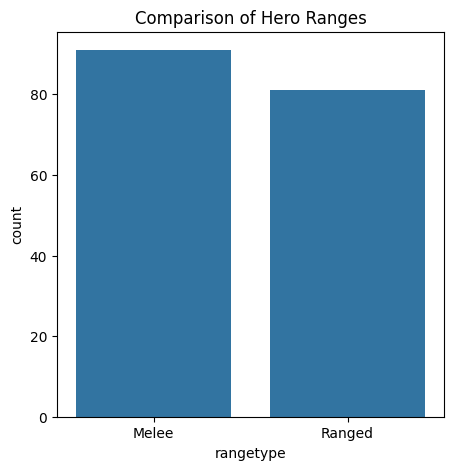

In [27]:
plt.figure(figsize=(5, 5))
plt.title("Comparison of Hero Ranges")
sns.countplot(x=champion_data['rangetype'], order=champion_data['rangetype'].value_counts().index)

### Champion Class

Distribution of primary class (`herotype`) across the roster.

<Axes: title={'center': 'Comparison of Hero Types'}, xlabel='herotype', ylabel='count'>

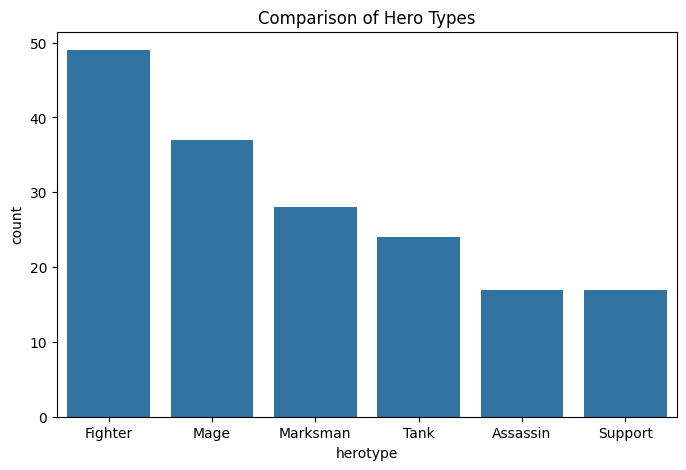

In [28]:
plt.figure(figsize=(8, 5))
plt.title("Comparison of Hero Types")
sns.countplot(x=champion_data['herotype'], order=champion_data['herotype'].value_counts().index)

### Secondary Class

Distribution of secondary class tags (`alttype`). Not every champion has one, which is why this doesn't sum to the full roster.

<Axes: title={'center': 'Comparison of Alternate Hero Types'}, xlabel='alttype', ylabel='count'>

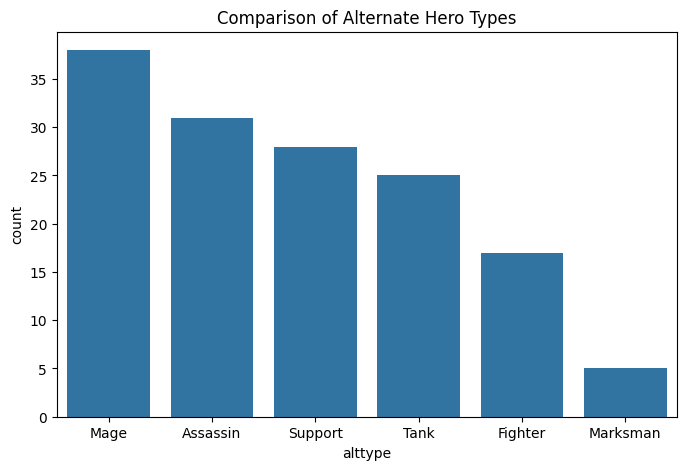

In [29]:
plt.figure(figsize=(8, 5))
plt.title("Comparison of Alternate Hero Types")
sns.countplot(x=champion_data['alttype'], order=champion_data['alttype'].value_counts().index)

### Class vs. Range Type

Combine the two to see how melee/ranged splits within each class. For example, are Fighters mostly melee, are Mages and Marksmen mostly ranged?

<Axes: title={'center': 'Comparison of Hero Types and their Ranges'}, xlabel='herotype', ylabel='count'>

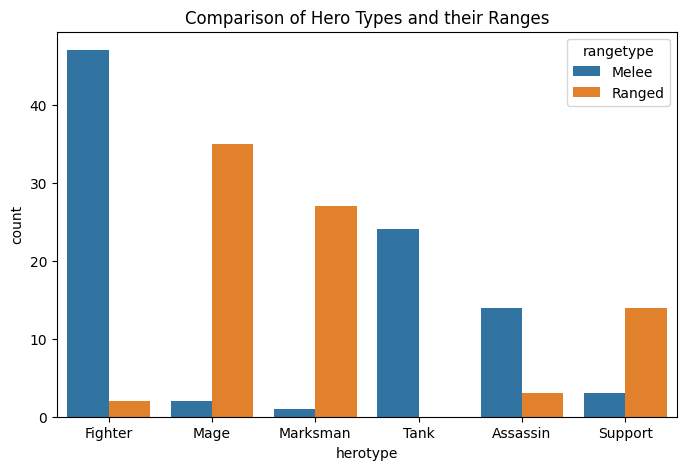

In [30]:
plt.figure(figsize=(8, 5))
plt.title("Comparison of Hero Types and their Ranges")
sns.countplot(x=champion_data['herotype'], order=champion_data['herotype'].value_counts().index, hue=champion_data['rangetype'])

### Difficulty Rating

How champions are distributed across Riot's 1-3 mechanical difficulty rating.

<Axes: title={'center': 'Comparison of Hero Difficulties'}, xlabel='difficulty', ylabel='count'>

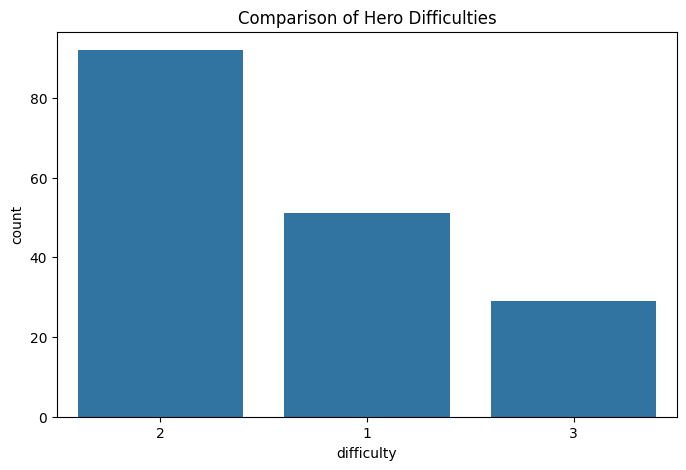

In [31]:
plt.figure(figsize=(8, 5))
plt.title("Comparison of Hero Difficulties")
sns.countplot(x=champion_data['difficulty'], order=champion_data['difficulty'].value_counts().index)

## Digging Deeper Into Class Identity

The visualisations above describe *what* categories exist. The next sections dig into *why* those categories look the way they do, using the numeric playstyle scores and base stats.

## Class Playstyle Fingerprints

Each champion has five 0-3 "playstyle" scores (`damage`, `toughness`, `control`, `mobility`, `utility`) set by Riot. Averaging these by `herotype` (class) shows how distinct the six classes really are.

In [32]:
playstyle_cols = ['damage', 'toughness', 'control', 'mobility', 'utility']
class_playstyle = champion_data.groupby('herotype')[playstyle_cols].mean().round(2)
class_playstyle

,damage,toughness,control,mobility,utility
herotype,,,,,
Assassin,2.88,1.24,1.41,2.53,1.18
Fighter,2.53,1.96,1.78,2.00,1.27
Mage,2.86,1.11,2.22,1.38,1.43
Marksman,2.93,1.11,1.54,1.93,1.25
Support,1.47,1.18,2.47,1.65,2.65
Tank,1.58,2.88,2.71,1.42,1.46


<Axes: title={'center': 'Average Playstyle Scores by Class'}, ylabel='herotype'>

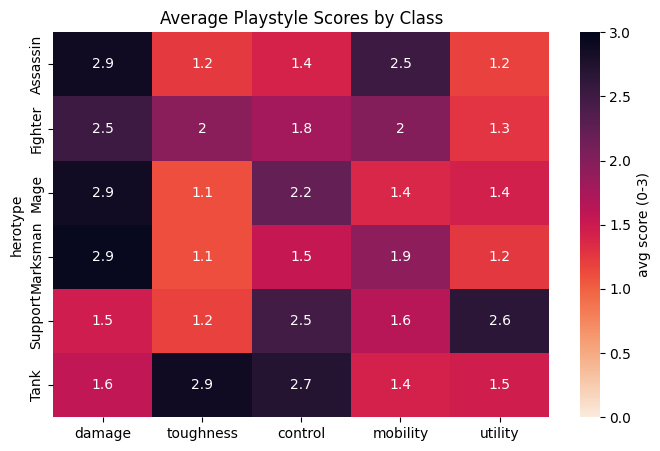

In [33]:
plt.figure(figsize=(8, 5))
plt.title("Average Playstyle Scores by Class")
sns.heatmap(class_playstyle, annot=True, cmap='rocket_r', vmin=0, vmax=3, cbar_kws={'label': 'avg score (0-3)'})

Assassins and Marksmen look almost identical on raw `damage`, but split apart on `mobility` where Assassins are much higher and `utility` where Marksmen are slightly higher. Tanks and Supports both score high on `control`, but Tanks pair it with `toughness` while Supports pair it with `utility`. This makes a good example of two classes sharing one dimension but differing on another.

## Base Stats by Class

Beyond the design-labeled playstyle scores, the underlying base stats (level-1 numbers before any items or levels) tell a similar story.

Text(0.5, 1.0, 'Base Movement Speed by Class')

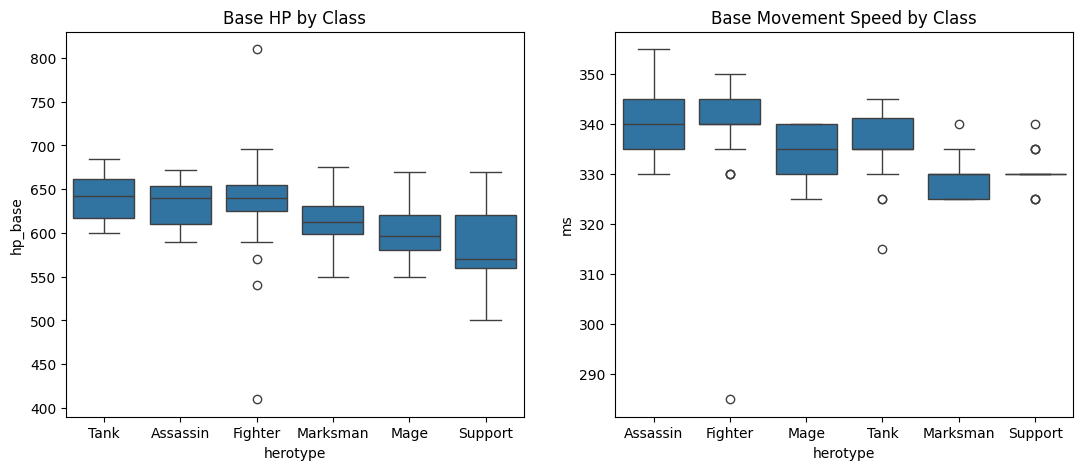

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = champion_data.groupby('herotype')['hp_base'].median().sort_values(ascending=False).index
sns.boxplot(data=champion_data, x='herotype', y='hp_base', order=order, ax=axes[0])
axes[0].set_title('Base HP by Class')

order_ms = champion_data.groupby('herotype')['ms'].median().sort_values(ascending=False).index
sns.boxplot(data=champion_data, x='herotype', y='ms', order=order_ms, ax=axes[1])
axes[1].set_title('Base Movement Speed by Class')

Tanks and Fighters carry the most base HP, as expected for frontline classes. Movement speed is much flatter across classes. Champion identity is expressed far more through HP/armour/resistances than through base MS.

## Correlation Between Stats

A correlation heatmap over the playstyle scores and key base stats shows which attributes tend to move together across the roster.

In [35]:
corr_cols = playstyle_cols + ['hp_base', 'arm_base', 'mr_base', 'dam_base', 'ms', 'difficulty']
corr = champion_data[corr_cols].corr()
corr

,damage,toughness,control,mobility,utility,hp_base,arm_base,mr_base,dam_base,ms,difficulty
damage,1.000000,-0.501219,-0.437284,0.212306,-0.380153,-0.064832,-0.421637,-0.019573,0.011919,0.076026,0.290628
toughness,-0.501219,1.000000,0.220002,-0.116361,-0.104304,0.423544,0.618614,0.280533,0.493070,0.247515,-0.302984
control,-0.437284,0.220002,1.000000,-0.323681,0.114477,-0.055992,0.063123,0.052818,-0.190368,-0.136002,-0.110134
mobility,0.212306,-0.116361,-0.323681,1.000000,-0.175191,0.070377,0.024718,0.117961,0.204670,0.114044,0.271676
utility,-0.380153,-0.104304,0.114477,-0.175191,1.000000,-0.250764,-0.044622,-0.208724,-0.365303,-0.170005,0.012700
hp_base,-0.064832,0.423544,-0.055992,0.070377,-0.250764,1.000000,0.473168,0.237323,0.451395,0.485841,-0.170194
arm_base,-0.421637,0.618614,0.063123,0.024718,-0.044622,0.473168,1.000000,0.313172,0.575293,0.296156,-0.200523
mr_base,-0.019573,0.280533,0.052818,0.117961,-0.208724,0.237323,0.313172,1.000000,0.450265,0.376658,-0.004331
dam_base,0.011919,0.493070,-0.190368,0.204670,-0.365303,0.451395,0.575293,0.450265,1.000000,0.418396,-0.063324
ms,0.076026,0.247515,-0.136002,0.114044,-0.170005,0.485841,0.296156,0.376658,0.418396,1.000000,-0.129285


<Axes: title={'center': 'Correlation Between Playstyle Scores, Base Stats, and Difficulty'}>

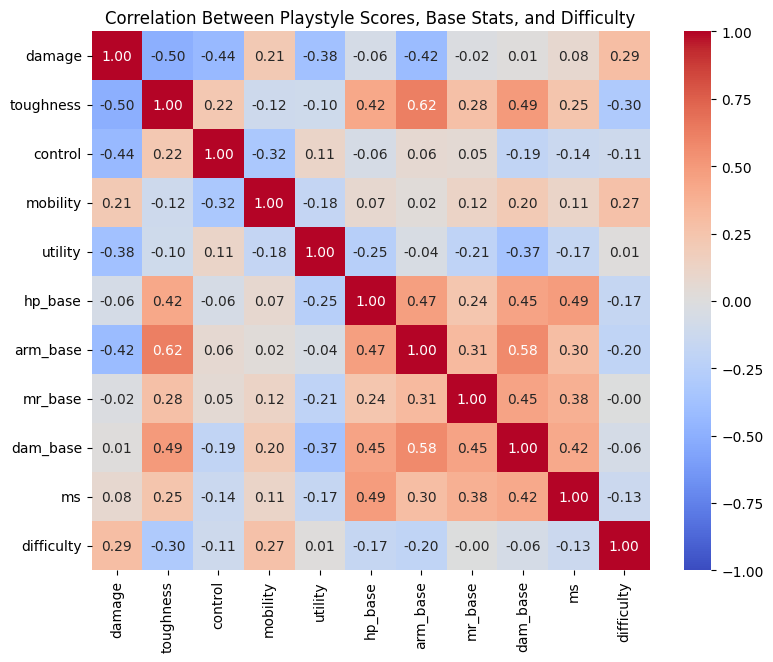

In [36]:

plt.figure(figsize=(9, 7))
plt.title("Correlation Between Playstyle Scores, Base Stats, and Difficulty")
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

`toughness` and `arm_base` correlate positively as expected. Tankier champions get more base armour. `toughness` correlates negatively with `damage`. The classic tankiness/damage trade-off baked into champion design. `difficulty` correlates most with `damage` and `mobility`, and negatively with `toughness`, hinting that Riot's mechanical-difficulty rating leans on "high skill expression through damage/mobility" more than on survivability.

Variance explained: PC1=40.6%, PC2=22.4%


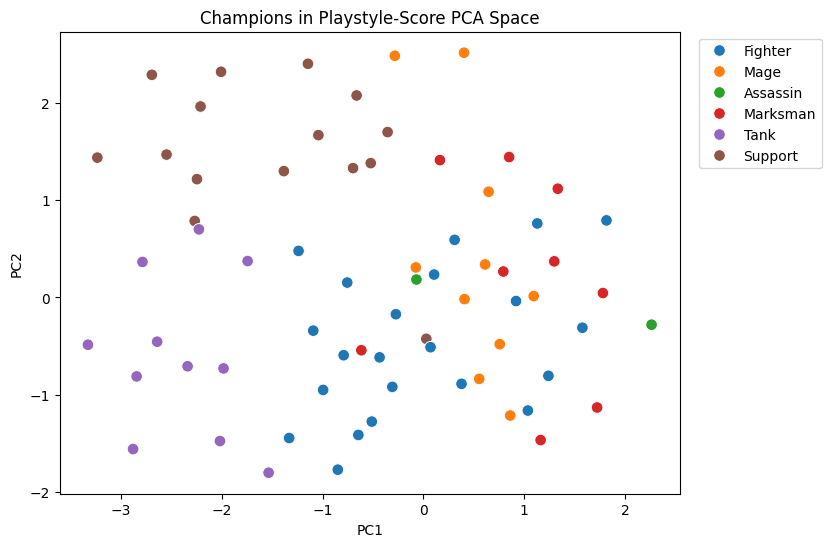

In [37]:
X = champion_data[playstyle_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
champion_data['pc1'] = pcs[:, 0]
champion_data['pc2'] = pcs[:, 1]

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=champion_data, x='pc1', y='pc2', hue='herotype', palette='tab10', s=70)
plt.title("Champions in Playstyle-Score PCA Space")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

Text(0.5, 25.722222222222214, 'K-Means cluster')

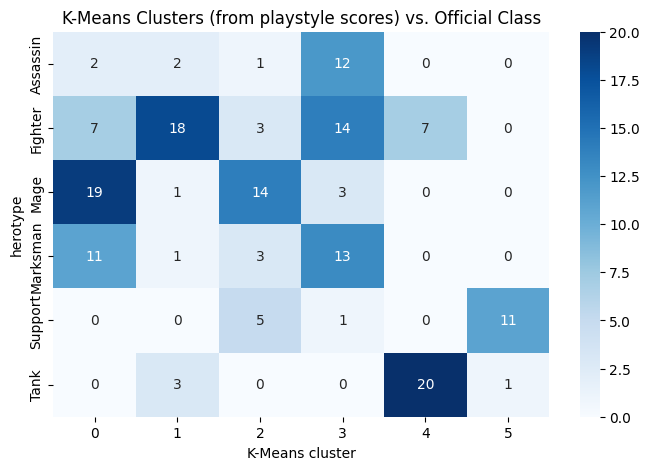

In [38]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
champion_data['cluster'] = kmeans.fit_predict(X_scaled)

cluster_vs_class = pd.crosstab(champion_data['herotype'], champion_data['cluster'])

plt.figure(figsize=(8, 5))
plt.title("K-Means Clusters (from playstyle scores) vs. Official Class")
sns.heatmap(cluster_vs_class, annot=True, fmt='d', cmap='Blues')
plt.xlabel('K-Means cluster')